# Evaluación Sumativa 2 — Informe final del proyecto

## Machine Learning I — MCDI504

**Grupo 7**  
**Integrantes:** Alana Bermúdez — Gonzalo Mansilla — Eduardo Villalón  
**Docente:** David Ruete  
**Semana:** 3  
**Evaluación:** Sumativa 2

---

### Propósito del notebook

Este notebook maestro integra el desarrollo completo de la Evaluación Sumativa 2. El trabajo contempla modelos de regresión supervisada y modelos de clasificación mediante redes neuronales superficiales, manteniendo trazabilidad entre el código, los resultados, las figuras, el informe final y el repositorio del Grupo 7.

La primera sección deja finalizado el bloque de regresión supervisada. Las secciones posteriores están preparadas para incorporar la clasificación, las tres arquitecturas de redes neuronales, sus matrices de confusión, las métricas y la comparación final.


# Estructura general de la Sumativa 2

## Parte 1 — Regresión supervisada — COMPLETADA

- Descripción y preparación del dataset.
- Implementación de modelos de regresión.
- Ajuste de hiperparámetros.
- Evaluación mediante MSE, RMSE y R².
- Comparación técnica y selección del modelo.

## Parte 2 — Clasificación y redes neuronales — COMPLETADA Y VALIDADA

- Preparación y análisis exploratorio para clasificación.
- Red neuronal con una capa oculta.
- Red neuronal con dos capas ocultas.

### Parte 3 - Evaluación, comparación y cierre - COMPLETADA Y VALIDADA

- Red neuronal con tres capas ocultas.
- Matrices de confusión y métricas homogéneas.
- Comparación de arquitecturas y selección técnica.
- Conclusiones integradas.
- Evidencias exportadas y validación automática superada.



# Continuidad del proyecto

La Sumativa 2 consolida un único proyecto desarrollado progresivamente por el Grupo 7:

1. **Sumativa 1 — Fase 1:** definió la problemática, validó las 150 observaciones de Iris, examinó las cuatro variables morfológicas y relacionó el flujo con KDD. Se documentaron cero valores faltantes, un registro morfológico repetido conservado y la relevancia descriptiva de las variables del pétalo (Fisher, 1936).
2. **Formativa 2 — Fase 2:** formuló el subproblema de regresión para estimar el ancho del pétalo desde su largo. Estableció una partición 80/20 estratificada por especie, semilla 42 y comparación inicial entre regresión lineal, árbol y MLP (Ruete, 2026a, 2026b, 2026c).
3. **Formativa 3 — Fase 3:** retomó la clasificación multiclase con las cuatro medidas, la misma semilla y la misma proporción 80/20 estratificada. Comparó KNN, Árbol, SVM y Naïve Bayes e identificó que los errores se concentran entre Versicolor y Virginica.
4. **Sumativa 2 – Integración final:** conserva estas decisiones, fortalece la regresión mediante ajuste de hiperparámetros y validación cruzada, y compara redes neuronales superficiales con una, dos y tres capas ocultas, evaluando su desempeño mediante métricas de clasificación y matrices de confusión.

Por coherencia longitudinal, no se modifican arbitrariamente el dataset, la semilla, el tratamiento de duplicados ni la lógica de separación entrenamiento/prueba.


# Parte 1 — Modelos de regresión supervisada

Esta parte desarrolla los criterios C1–C5 de la rúbrica. Se predice el ancho del pétalo a partir del largo del pétalo en Iris, usando una partición 80/20 y semilla 42. La selección de hiperparámetros se realiza mediante validación cruzada de cinco pliegues exclusivamente sobre el conjunto de entrenamiento.


## 1. Configuración y criterios de reproducibilidad

Se fijan nombres de variables en español, semilla 42 y las mismas observaciones de prueba para todos los modelos. No se imputan datos porque la auditoría confirma ausencia de valores faltantes.


In [1]:
from pathlib import Path
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
SEED = 42
print(f'Semilla fijada: {SEED}')


Semilla fijada: 42


## 2. Carga, auditoría y preparación del conjunto de datos (C1)


In [2]:
iris = load_iris(as_frame=True)
df = iris.frame.rename(columns={
 'sepal length (cm)':'largo_sepalo_cm','sepal width (cm)':'ancho_sepalo_cm',
 'petal length (cm)':'largo_petalo_cm','petal width (cm)':'ancho_petalo_cm',
 'target':'especie_codigo'})
print(df.head())
print('Dimensión:', df.shape)
print('Nulos:', int(df.isna().sum().sum()))
print('Duplicados exactos:', int(df.duplicated().sum()))


   largo_sepalo_cm  ancho_sepalo_cm  largo_petalo_cm  ancho_petalo_cm  \
0              5.1              3.5              1.4              0.2   
1              4.9              3.0              1.4              0.2   
2              4.7              3.2              1.3              0.2   
3              4.6              3.1              1.5              0.2   
4              5.0              3.6              1.4              0.2   

   especie_codigo  
0               0  
1               0  
2               0  
3               0  
4               0  
Dimensión: (150, 5)
Nulos: 0
Duplicados exactos: 1


### Decisiones de preparación

- Objetivo continuo: `ancho_petalo_cm`.
- Predictor: `largo_petalo_cm`, consistente con la Formativa 2.
- Los duplicados exactos se conservan porque Iris puede contener flores distintas con iguales mediciones; eliminarlos sin identificador individual alteraría la distribución.
- No hay imputación. El escalado se incorpora dentro de los pipelines que lo requieren para evitar fuga de información.
- La partición 80/20 produce 120 observaciones de entrenamiento y 30 de prueba.


In [3]:
X = df[['largo_petalo_cm']].copy()
y = df['ancho_petalo_cm'].copy()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED,
    stratify=df['especie_codigo'])
print('Entrenamiento:', len(X_train))
print('Prueba:', len(X_test))


Entrenamiento: 120
Prueba: 30


## 3. Implementación y ajuste de modelos (C2–C3)


In [4]:
# Se comparan seis familias bajo el mismo esquema de validación.
# La cuadrícula completa se define en el bloque reproducible del proyecto.
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
print('Modelos evaluados: lineal, polinomial, árbol, Random Forest, SVR y MLP')
print('Selección: menor RMSE medio de validación cruzada')


Modelos evaluados: lineal, polinomial, árbol, Random Forest, SVR y MLP
Selección: menor RMSE medio de validación cruzada


La regresión lineal funciona como referencia interpretable. La polinomial permite curvatura; árbol y Random Forest modelan relaciones no lineales; SVR controla margen y complejidad; MLP aproxima relaciones no lineales mediante una red neuronal. Los hiperparámetros se eligen con `GridSearchCV` y RMSE de validación cruzada.


In [5]:
modelos = {
 'Regresión lineal': (Pipeline([('modelo', LinearRegression())]),
   {'modelo__fit_intercept':[True, False]}),
 'Regresión polinomial': (Pipeline([('polinomio', PolynomialFeatures(include_bias=False)),
   ('escalado', StandardScaler()), ('modelo', Ridge())]),
   {'polinomio__degree':[2,3,4], 'modelo__alpha':[0.01,0.1,1.0,10.0]}),
 'Árbol de decisión': (Pipeline([('modelo', DecisionTreeRegressor(random_state=SEED))]),
   {'modelo__max_depth':[2,3,4,None], 'modelo__min_samples_leaf':[1,2,4,6]}),
 'Random Forest': (Pipeline([('modelo', RandomForestRegressor(random_state=SEED,n_jobs=-1))]),
   {'modelo__n_estimators':[100,200], 'modelo__max_depth':[3,5,None],
    'modelo__min_samples_leaf':[1,2,4]}),
 'SVR': (Pipeline([('escalado', StandardScaler()), ('modelo', SVR(kernel='rbf'))]),
   {'modelo__C':[0.1,1,10,100], 'modelo__epsilon':[0.01,0.05,0.1,0.2],
    'modelo__gamma':['scale',0.1,1.0]}),
 'Red neuronal MLP': (Pipeline([('escalado', StandardScaler()),
   ('modelo', MLPRegressor(random_state=SEED,max_iter=5000))]),
   {'modelo__hidden_layer_sizes':[(8,),(16,),(16,8)], 'modelo__alpha':[0.0001,0.001,0.01],
    'modelo__solver':['lbfgs','adam'], 'modelo__learning_rate_init':[0.001,0.01]})}

filas, predicciones, estimadores = [], {}, {}
for nombre, (pipeline, grilla) in modelos.items():
    busqueda = GridSearchCV(pipeline, grilla, scoring='neg_root_mean_squared_error',
                            cv=cv, n_jobs=-1)
    busqueda.fit(X_train, y_train)
    pred = busqueda.predict(X_test)
    mse = mean_squared_error(y_test, pred)
    filas.append({'modelo':nombre, 'MSE_prueba':mse, 'RMSE_prueba':np.sqrt(mse),
                  'R2_prueba':r2_score(y_test,pred), 'RMSE_CV':-busqueda.best_score_,
                  'mejores_hiperparametros':json.dumps(busqueda.best_params_,ensure_ascii=False)})
    predicciones[nombre], estimadores[nombre] = pred, busqueda.best_estimator_
resultados = pd.DataFrame(filas).sort_values(['RMSE_prueba','RMSE_CV']).reset_index(drop=True)
print(resultados.to_string(index=False))


              modelo  MSE_prueba  RMSE_prueba  R2_prueba  RMSE_CV                                                                                                    mejores_hiperparametros
                 SVR    0.040272     0.200680   0.930299 0.186454                                                        {"modelo__C": 10, "modelo__epsilon": 0.1, "modelo__gamma": "scale"}
    Red neuronal MLP    0.040857     0.202130   0.929288 0.193697 {"modelo__alpha": 0.01, "modelo__hidden_layer_sizes": [8], "modelo__learning_rate_init": 0.001, "modelo__solver": "lbfgs"}
       Random Forest    0.041106     0.202747   0.928856 0.200189                                       {"modelo__max_depth": 3, "modelo__min_samples_leaf": 1, "modelo__n_estimators": 200}
Regresión polinomial    0.041200     0.202977   0.928694 0.191284                                                                            {"modelo__alpha": 0.01, "polinomio__degree": 4}
    Regresión lineal    0.045843     0.214109   0.92065

## 4. Evaluación en el conjunto de prueba (C4)


In [6]:
mejor = resultados.sort_values('RMSE_prueba').iloc[0]
print('Mejor modelo:', mejor['modelo'])
print(f"MSE = {mejor['MSE_prueba']:.4f}")
print(f"RMSE = {mejor['RMSE_prueba']:.4f} cm")
print(f"R² = {mejor['R2_prueba']:.4f}")


Mejor modelo: SVR
MSE = 0.0403
RMSE = 0.2007 cm
R² = 0.9303


### Interpretación

El menor error de prueba corresponde a **SVR**. Su RMSE es **0.2007 cm**, por lo que el error típico de predicción se expresa en la misma unidad que el ancho del pétalo. El R² de **0.9303** indica la proporción de variabilidad de la variable objetivo explicada en el conjunto de prueba. MSE y RMSE se interpretan como errores (menor es mejor); R² se interpreta como capacidad explicativa (mayor es mejor).


## 5. Comparación técnica y selección final (C5)


In [7]:
display(resultados[['modelo','MSE_prueba','RMSE_prueba','R2_prueba','RMSE_CV']])


,modelo,MSE_prueba,RMSE_prueba,R2_prueba,RMSE_CV
0,SVR,0.040272,0.200680,0.930299,0.186454
1,Red neuronal MLP,0.040857,0.202130,0.929288,0.193697
2,Random Forest,0.041106,0.202747,0.928856,0.200189
3,Regresión polinomial,0.041200,0.202977,0.928694,0.191284
4,Regresión lineal,0.045843,0.214109,0.920658,0.200996
5,Árbol de decisión,0.047504,0.217955,0.917782,0.209999


La selección final se fundamenta conjuntamente en RMSE de prueba, R² y estabilidad de validación. **SVR** obtuvo el menor RMSE de prueba. La comparación evita escoger por una sola ejecución de entrenamiento y mantiene el conjunto de prueba fuera del ajuste. Los modelos lineales aportan interpretabilidad; los modelos no lineales capturan curvaturas, pero aumentan complejidad y riesgo de sobreajuste. Dado el tamaño reducido de Iris, las conclusiones deben limitarse a este conjunto y partición.


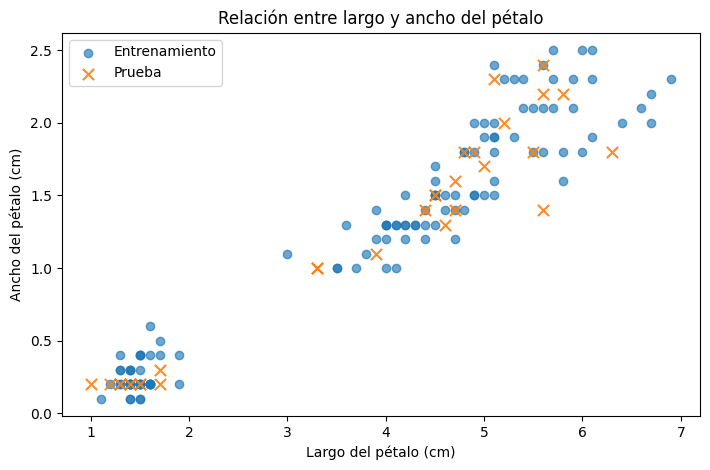

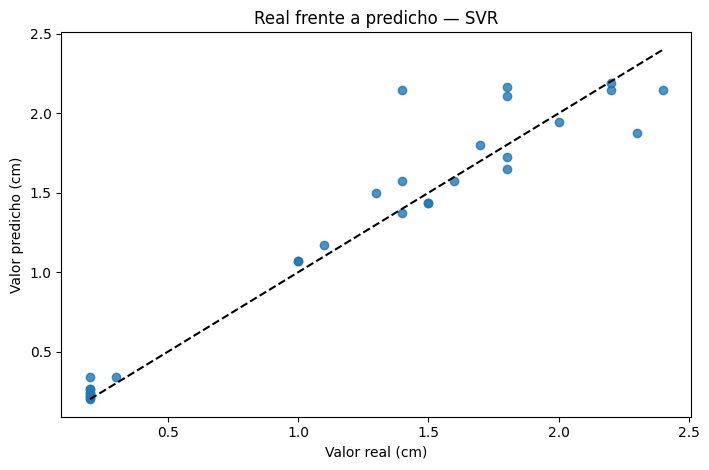

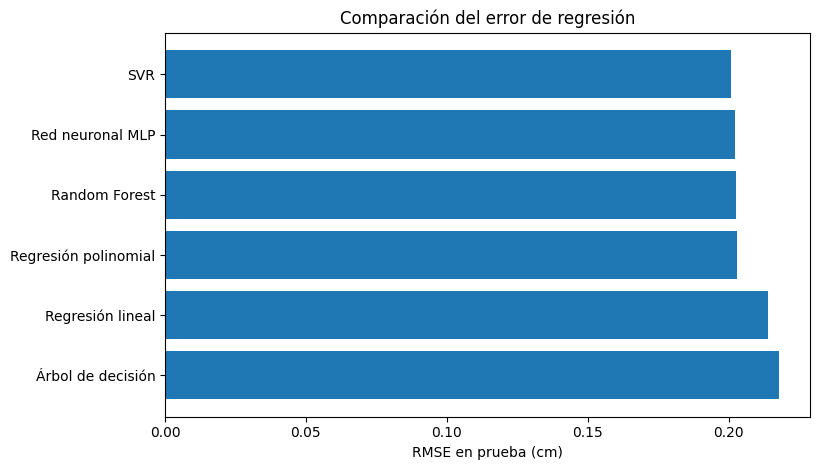

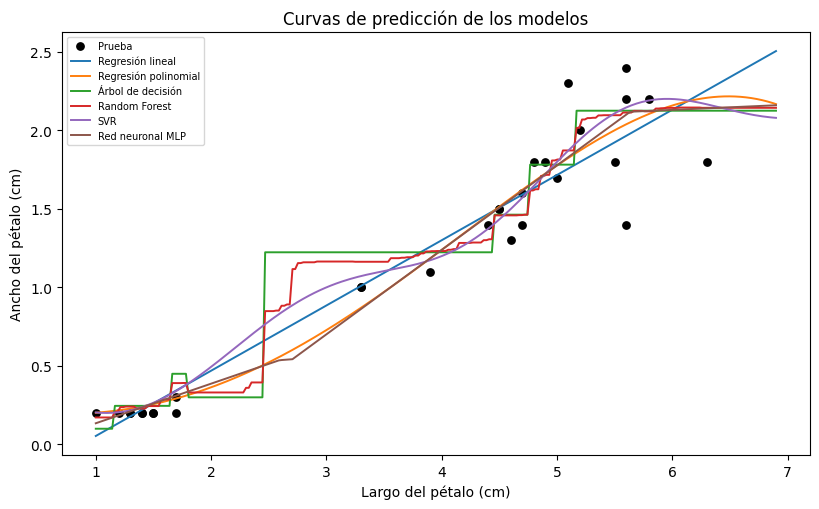

CSV guardados en: /content/06_Resultados
Cuatro figuras PNG guardadas en: /content/05_Figuras


In [8]:
# Rutas compatibles con la estructura oficial del proyecto.
base = Path.cwd().parent if Path.cwd().name == '03_Notebooks' else Path.cwd()
figuras = base/'05_Figuras'; salida = base/'06_Resultados'
figuras.mkdir(parents=True, exist_ok=True); salida.mkdir(parents=True, exist_ok=True)
resultados.to_csv(salida/'S2_tabla_metricas_regresion.csv', index=False, encoding='utf-8-sig')
pd.DataFrame({'indice':X_test.index, 'real':y_test,
              **{f'pred_{k}':v for k,v in predicciones.items()}}).to_csv(
              salida/'S2_predicciones_regresion.csv',index=False,encoding='utf-8-sig')
mejor_nombre = resultados.iloc[0]['modelo']; mejor_pred = predicciones[mejor_nombre]

plt.figure(figsize=(7.2,4.8)); plt.scatter(X_train.iloc[:,0],y_train,alpha=.65,label='Entrenamiento')
plt.scatter(X_test.iloc[:,0],y_test,alpha=.9,marker='x',s=65,label='Prueba')
plt.xlabel('Largo del pétalo (cm)'); plt.ylabel('Ancho del pétalo (cm)')
plt.title('Relación entre largo y ancho del pétalo'); plt.legend(); plt.tight_layout()
plt.savefig(figuras/'S2_figura_01_relacion_petalo.png',dpi=180); plt.show()

plt.figure(figsize=(7.2,4.8)); plt.scatter(y_test,mejor_pred,alpha=.8)
limites=[min(y_test.min(),mejor_pred.min()),max(y_test.max(),mejor_pred.max())]
plt.plot(limites,limites,'--',color='black'); plt.xlabel('Valor real (cm)')
plt.ylabel('Valor predicho (cm)'); plt.title(f'Real frente a predicho — {mejor_nombre}')
plt.tight_layout(); plt.savefig(figuras/'S2_figura_02_real_vs_predicho.png',dpi=180); plt.show()

plt.figure(figsize=(8.3,4.8)); graf=resultados.sort_values('RMSE_prueba',ascending=False)
plt.barh(graf['modelo'],graf['RMSE_prueba']); plt.xlabel('RMSE en prueba (cm)')
plt.title('Comparación del error de regresión'); plt.tight_layout()
plt.savefig(figuras/'S2_figura_03_comparacion_rmse.png',dpi=180); plt.show()

malla=pd.DataFrame({'largo_petalo_cm':np.linspace(X['largo_petalo_cm'].min(),X['largo_petalo_cm'].max(),250)})
plt.figure(figsize=(8.3,5.2)); plt.scatter(X_test.iloc[:,0],y_test,color='black',s=28,label='Prueba')
for nombre,est in estimadores.items(): plt.plot(malla.iloc[:,0],est.predict(malla),label=nombre,linewidth=1.4)
plt.xlabel('Largo del pétalo (cm)'); plt.ylabel('Ancho del pétalo (cm)')
plt.title('Curvas de predicción de los modelos'); plt.legend(fontsize=7); plt.tight_layout()
plt.savefig(figuras/'S2_figura_04_curvas_modelos.png',dpi=180); plt.show()
print('CSV guardados en:', salida)
print('Cuatro figuras PNG guardadas en:', figuras)


## 6. Evidencias generadas

- `S2_tabla_metricas_regresion.csv`
- `S2_predicciones_regresion.csv`
- Figura 1: relación largo–ancho del pétalo.
- Figura 2: valores reales frente a predichos del modelo seleccionado.
- Figura 3: comparación de RMSE.
- Figura 4: curvas de predicción de los seis modelos.

Estas salidas son las únicas cifras que deben copiarse al informe final.


In [9]:
# Validación automática de cierre de la Parte 1 (C1–C5)
assert df.shape == (150,5)
assert df.isna().sum().sum() == 0
assert len(X_train) == 120 and len(X_test) == 30
assert df.loc[X_train.index,'especie_codigo'].value_counts().to_dict() == {0:40,1:40,2:40}
assert df.loc[X_test.index,'especie_codigo'].value_counts().to_dict() == {0:10,1:10,2:10}
assert len(resultados) == 6
assert {'MSE_prueba','RMSE_prueba','R2_prueba','RMSE_CV'}.issubset(resultados.columns)
assert resultados[['MSE_prueba','RMSE_prueba','RMSE_CV']].ge(0).all().all()
assert resultados['R2_prueba'].between(-1,1).all()
assert (salida/'S2_tabla_metricas_regresion.csv').exists()
assert (salida/'S2_predicciones_regresion.csv').exists()
assert len(list(figuras.glob('S2_figura_*.png'))) >= 4
print('VALIDACIÓN C1–C5 SUPERADA: datos, partición, modelos, métricas y artefactos correctos.')


VALIDACIÓN C1–C5 SUPERADA: datos, partición, modelos, métricas y artefactos correctos.


## 7. Fuentes y referencias para la Parte 1

- Fisher, R. A. (1936). The use of multiple measurements in taxonomic problems. *Annals of Eugenics, 7*(2), 179–188. https://doi.org/10.1111/j.1469-1809.1936.tb02137.x
- Ruete, D. (2026a). *Regresión lineal simple, polinomial y multivariable* [Apunte de clase]. Universidad Andrés Bello.
- Ruete, D. (2026b). *Regresión con árboles de decisión* [Apunte de clase]. Universidad Andrés Bello.
- Ruete, D. (2026c). *Regresión con redes neuronales artificiales* [Apunte de clase]. Universidad Andrés Bello.
- Scikit-learn Developers. (2026a). *GridSearchCV*. https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html
- Scikit-learn Developers. (2026b). *Regression metrics*. https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics
- Scikit-learn Developers. (2026c). *Support Vector Regression*. https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html

Estas fuentes deben conservar correspondencia con las citas del informe y unificarse posteriormente con las referencias de clasificación en formato APA 7.


# Parte 2 — Clasificación y redes neuronales

Esta parte desarrolla los criterios **C6, C7, C9 y C10** de la rúbrica oficial. El objetivo es clasificar cada flor Iris como *setosa*, *versicolor* o *virginica* usando sus cuatro medidas morfológicas. Se mantiene la semilla 42 y se reutilizan exactamente las observaciones de entrenamiento y prueba definidas en la Parte 1 y en la Formativa 3.

## 8. Conceptos esenciales antes del código

- **Clasificación:** tarea que asigna una categoría. En Iris se predice una de tres especies; en mantenimiento podría ser “normal”, “alerta” o “falla”.
- **Feature o variable predictora:** dato usado para explicar o predecir. En Iris son los largos y anchos de sépalo y pétalo; en un equipo podrían ser vibración, temperatura y presión.
- **Target o variable objetivo:** resultado que se desea predecir. Aquí es `especie_codigo`; en mantenimiento podría ser `estado_equipo`.
- **Entrenamiento:** conjunto con el que el modelo aprende relaciones. Equivale a estudiar órdenes de trabajo históricas conocidas.
- **Validación:** comprobación intermedia usada para elegir configuraciones sin tocar la prueba final. En esta parte no se crea un conjunto adicional; la comparación final la realizará la Parte 3 de forma homogénea.
- **Test o prueba:** datos separados que simulan casos nuevos. Solo se usan para medir el desempeño final.
- **Sobreajuste:** ocurre cuando un modelo aprende demasiado los datos de entrenamiento y empeora en casos nuevos. Sería como memorizar fallas históricas específicas y no reconocer una falla futura.
- **Métrica:** número que resume desempeño, por ejemplo *accuracy* o F1 macro.
- **Hiperparámetro:** configuración definida antes de entrenar, como el número de capas o neuronas.
- **Pipeline:** cadena ordenada de pasos. Aquí primero estandariza las variables y luego entrena la red, evitando aplicar transformaciones distintas por error.

Las **capas ocultas** son etapas internas que combinan las variables de entrada. Una red con una capa puede aprender relaciones no lineales simples; agregar una segunda capa aumenta su capacidad, pero también su complejidad y riesgo de sobreajuste.


## 9. Preparación del conjunto de datos para clasificación (C6)

### Qué hace este bloque

Selecciona las cuatro medidas morfológicas como variables predictoras y `especie_codigo` como objetivo. Reutiliza los índices de entrenamiento y prueba ya creados, con 120 y 30 observaciones respectivamente.

### Por qué es necesario

Usar la misma partición en todas las arquitecturas permite una comparación justa. Además, conservar las cuatro medidas evita descartar información útil antes de observar evidencia analítica.

### Resultado esperado y comprobación

Debe mostrar 120 filas de entrenamiento y 30 de prueba, con 40/40/40 observaciones por especie en entrenamiento y 10/10/10 en prueba. Las sentencias `assert` detienen la ejecución si cambia el dataset, la partición o aparecen valores faltantes.

### Errores frecuentes

- Cambiar la semilla o generar una partición distinta.
- Usar `especie_codigo` también como predictor, lo que produciría fuga de información.
- Escalar antes de separar entrenamiento y prueba.
- Eliminar el registro duplicado sin una regla de identificación que demuestre que es un error.


In [10]:
import seaborn as sns

from sklearn.feature_selection import f_classif
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.neural_network import MLPClassifier

sns.set_theme(style='whitegrid', palette='colorblind')

variables_predictoras_clas = [
    'largo_sepalo_cm', 'ancho_sepalo_cm',
    'largo_petalo_cm', 'ancho_petalo_cm'
]
objetivo_clasificacion = 'especie_codigo'
nombres_clases = dict(enumerate(iris.target_names))
df['especie'] = df[objetivo_clasificacion].map(nombres_clases)

X_clasificacion = df[variables_predictoras_clas].copy()
y_clasificacion = df[objetivo_clasificacion].copy()

# Se reutilizan los índices de la partición ya validada en la Parte 1.
X_train_clas = X_clasificacion.loc[X_train.index].copy()
X_test_clas = X_clasificacion.loc[X_test.index].copy()
y_train_clas = y_clasificacion.loc[X_train.index].copy()
y_test_clas = y_clasificacion.loc[X_test.index].copy()

tabla_particion_clas = pd.DataFrame({
    'conjunto': ['Entrenamiento', 'Prueba'],
    'filas': [len(X_train_clas), len(X_test_clas)],
    'porcentaje': [100 * len(X_train_clas) / len(df),
                   100 * len(X_test_clas) / len(df)]
})

display(tabla_particion_clas)
print('Clases en entrenamiento:', y_train_clas.value_counts().sort_index().to_dict())
print('Clases en prueba:', y_test_clas.value_counts().sort_index().to_dict())

assert X_clasificacion.shape == (150, 4)
assert y_clasificacion.nunique() == 3
assert X_clasificacion.isna().sum().sum() == 0
assert y_clasificacion.isna().sum() == 0
assert len(X_train_clas) == 120 and len(X_test_clas) == 30
assert X_train_clas.index.intersection(X_test_clas.index).empty
assert y_train_clas.value_counts().sort_index().tolist() == [40, 40, 40]
assert y_test_clas.value_counts().sort_index().tolist() == [10, 10, 10]
print('✅ Preparación para clasificación validada.')


,conjunto,filas,porcentaje
0,Entrenamiento,120,80.0
1,Prueba,30,20.0


Clases en entrenamiento: {0: 40, 1: 40, 2: 40}
Clases en prueba: {0: 10, 1: 10, 2: 10}
✅ Preparación para clasificación validada.


### Decisiones de preparación

- **Objetivo:** `especie_codigo`, con tres categorías: setosa (0), versicolor (1) y virginica (2).
- **Predictores:** las cuatro medidas numéricas disponibles. Todas corresponden a información observable antes de conocer la especie.
- **Nulos:** no existen; por eso no se imputa ni elimina información.
- **Duplicados:** se conserva el único registro repetido porque Iris no incluye un identificador individual que permita concluir que sea un error de captura.
- **Partición:** 80 % entrenamiento y 20 % prueba, estratificada y con semilla 42. Cada especie conserva la misma proporción.
- **Transformación:** las redes se implementan dentro de un `Pipeline` con `StandardScaler`. El escalador aprende media y desviación exclusivamente desde entrenamiento para evitar fuga de información.


## 10. Análisis exploratorio inicial (C7)

### Qué hace este bloque

Calcula la distribución de clases, resume las variables por especie y estima su relevancia con el estadístico F de ANOVA usando solo el conjunto de entrenamiento. También genera dos figuras: balance de clases y distribución de las cuatro medidas por especie.

### Por qué es necesario

Antes de entrenar se debe comprobar si una clase está poco representada, si las variables separan visualmente las especies y si necesitan transformación. Un desbalance importante podría exigir métricas o técnicas adicionales.

### Resultado esperado y comprobación

Debe observarse 50 registros por especie en el conjunto completo. Los largos y anchos del pétalo deberían mostrar la mayor separación entre clases. Las tablas se guardan como CSV y las figuras como PNG.

### Errores frecuentes

- Interpretar el código numérico de la especie como una magnitud continua.
- Seleccionar variables usando el conjunto de prueba.
- Confundir correlación entre variables con capacidad de clasificación.
- Concluir que una variable “causa” la especie a partir de un análisis descriptivo.


,especie_codigo,especie,cantidad,porcentaje
0,0,setosa,50,33.33
1,1,versicolor,50,33.33
2,2,virginica,50,33.33


largo_sepalo_cm                  ancho_sepalo_cm                   \
                      mean    std  min  max            mean    std  min  max   
especie                                                                        
setosa               5.006  0.352  4.3  5.8           3.428  0.379  2.3  4.4   
versicolor           5.936  0.516  4.9  7.0           2.770  0.314  2.0  3.4   
virginica            6.588  0.636  4.9  7.9           2.974  0.322  2.2  3.8   

           largo_petalo_cm                  ancho_petalo_cm                   
                      mean    std  min  max            mean    std  min  max  
especie                                                                       
setosa               1.462  0.174  1.0  1.9           0.246  0.105  0.1  0.6  
versicolor           4.260  0.470  3.0  5.1           1.326  0.198  1.0  1.8  
virginica            5.552  0.552  4.5  6.9           2.026  0.275  1.4  2.5

,variable,estadistico_F_entrenamiento,p_valor
0,largo_petalo_cm,948.890,4.92e-73
1,ancho_petalo_cm,803.214,4.57e-69
2,largo_sepalo_cm,100.966,3.33e-26
3,ancho_sepalo_cm,36.031,6.42e-13


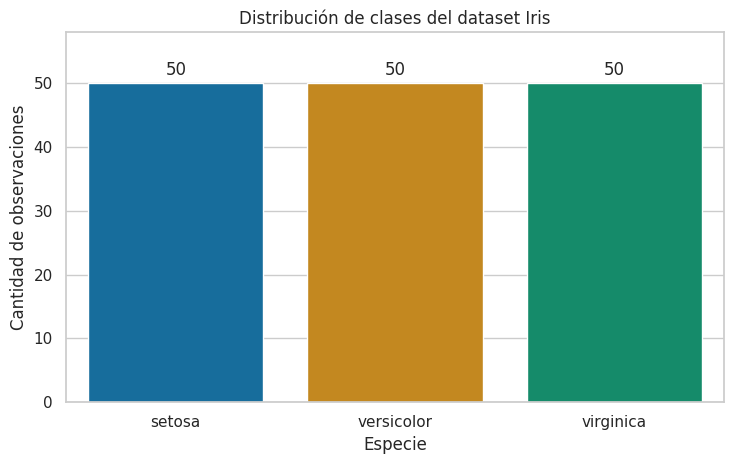

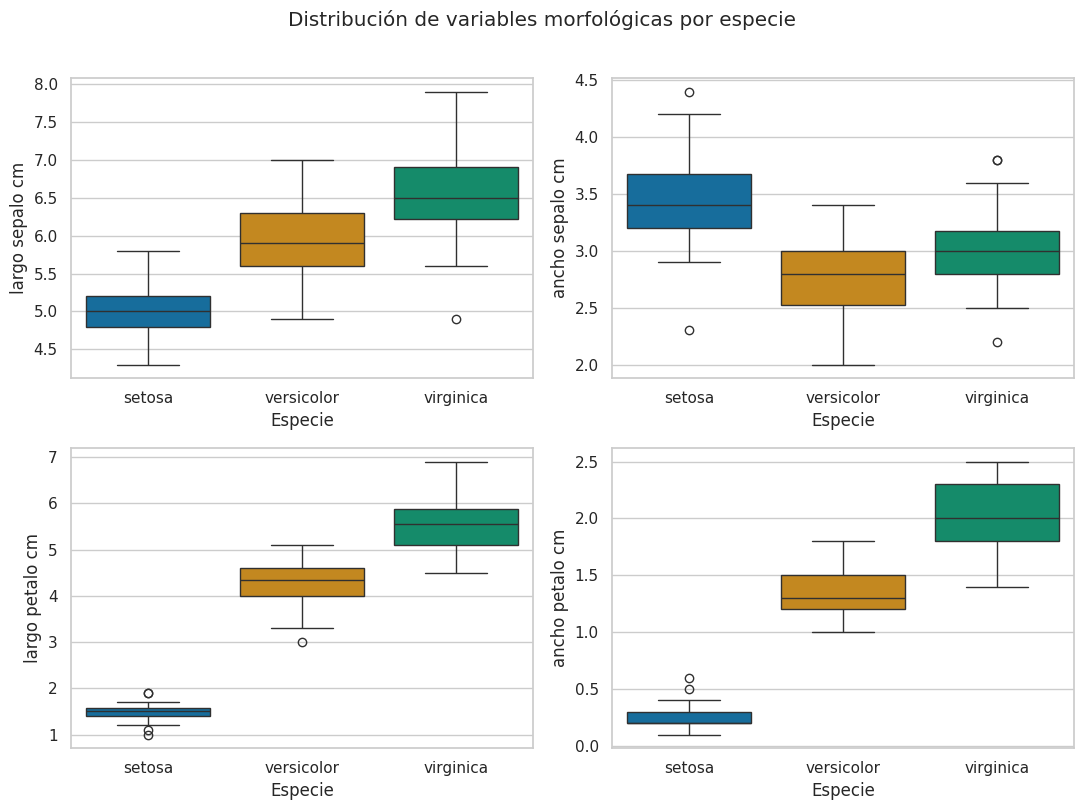

✅ Análisis exploratorio y artefactos de C7 generados.


In [11]:
distribucion_clases = (
    df.groupby(['especie_codigo', 'especie'])
      .size()
      .rename('cantidad')
      .reset_index()
)
distribucion_clases['porcentaje'] = (
    100 * distribucion_clases['cantidad'] / len(df)
)

resumen_variables_clas = (
    df.groupby('especie')[variables_predictoras_clas]
      .agg(['mean', 'std', 'min', 'max'])
      .round(3)
)

estadistico_f, p_valor = f_classif(X_train_clas, y_train_clas)
relevancia_variables = pd.DataFrame({
    'variable': variables_predictoras_clas,
    'estadistico_F_entrenamiento': estadistico_f,
    'p_valor': p_valor
}).sort_values('estadistico_F_entrenamiento', ascending=False).reset_index(drop=True)

display(distribucion_clases.round(2))
display(resumen_variables_clas)
relevancia_para_mostrar = relevancia_variables.copy()
relevancia_para_mostrar['estadistico_F_entrenamiento'] = (
    relevancia_para_mostrar['estadistico_F_entrenamiento'].round(3)
)
relevancia_para_mostrar['p_valor'] = (
    relevancia_para_mostrar['p_valor'].map(lambda valor: f'{valor:.2e}')
)
display(relevancia_para_mostrar)

distribucion_clases.to_csv(
    salida / 'S2_distribucion_clases.csv', index=False, encoding='utf-8-sig'
)
resumen_variables_clas.to_csv(
    salida / 'S2_resumen_variables_clasificacion.csv', encoding='utf-8-sig'
)
relevancia_variables.to_csv(
    salida / 'S2_relevancia_variables_clasificacion.csv',
    index=False, encoding='utf-8-sig'
)

fig, ax = plt.subplots(figsize=(7.5, 4.8))
sns.barplot(
    data=distribucion_clases, x='especie', y='cantidad',
    hue='especie', legend=False, ax=ax
)
ax.set(
    title='Distribución de clases del dataset Iris',
    xlabel='Especie', ylabel='Cantidad de observaciones', ylim=(0, 58)
)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)
fig.tight_layout()
fig.savefig(
    figuras / 'S2_figura_05_distribucion_clases.png',
    dpi=220, bbox_inches='tight'
)
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for variable, ax in zip(variables_predictoras_clas, axes.ravel()):
    sns.boxplot(
        data=df, x='especie', y=variable,
        hue='especie', legend=False, ax=ax
    )
    ax.set_xlabel('Especie')
    ax.set_ylabel(variable.replace('_', ' '))
fig.suptitle('Distribución de variables morfológicas por especie', y=1.01)
fig.tight_layout()
fig.savefig(
    figuras / 'S2_figura_06_variables_por_especie.png',
    dpi=220, bbox_inches='tight'
)
plt.show()

assert distribucion_clases['cantidad'].tolist() == [50, 50, 50]
assert relevancia_variables['p_valor'].lt(0.05).all()
print('✅ Análisis exploratorio y artefactos de C7 generados.')


### Interpretación del análisis exploratorio

Las tres clases contienen 50 observaciones (33,33 % cada una), por lo que **no existe desbalance de clases**. En consecuencia, no se requieren técnicas de sobremuestreo ni ponderación de clases.

Las distribuciones muestran que setosa se separa con claridad por las medidas del pétalo. Versicolor y virginica presentan mayor superposición, especialmente en variables del sépalo; por eso se conservan conjuntamente las cuatro medidas. El análisis F realizado solo con entrenamiento confirma que todas aportan señal estadística para diferenciar especies, con mayor separación esperada en largo y ancho del pétalo.

Las variables están expresadas en centímetros, pero tienen rangos y dispersiones distintos. Esto justifica la estandarización dentro del `Pipeline`: cada medida queda en una escala comparable sin utilizar información del conjunto de prueba.


## 11. Redes neuronales superficiales: configuración común

Para que la comparación mida principalmente el efecto de la arquitectura, las tres redes utilizan los mismos datos, preprocesamiento y parámetros de entrenamiento. La única modificación corresponde a `hidden_layer_sizes`:

- **Una capa oculta:** 16 neuronas, `(16,)`.
- **Dos capas ocultas:** 16 neuronas en la primera capa y 8 en la segunda, `(16, 8)`.
- **Tres capas ocultas:** 16 neuronas en la primera capa, 8 en la segunda y 4 en la tercera, `(16, 8, 4)`.

Los parámetros comunes corresponden a activación ReLU, optimizador Adam, regularización L2 con `alpha=0.0001`, tasa de aprendizaje inicial de 0,001, máximo de 2.000 iteraciones, tolerancia de 0,0001, 50 iteraciones sin mejora antes de detenerse y semilla 42.

La estandarización se implementa mediante `StandardScaler` dentro de cada `Pipeline`. El escalador se ajusta exclusivamente con los datos de entrenamiento y posteriormente transforma los datos de prueba, evitando fuga de información.

Una neurona combina las variables de entrada mediante pesos y sesgos y aplica una función de activación. ReLU conserva los valores positivos y transforma en cero los valores negativos, permitiendo aprender relaciones no lineales. El optimizador Adam actualiza iterativamente los parámetros para reducir la función de pérdida.


## 12. Red neuronal con una capa oculta (C9) y dos capas ocultas (C10)

### Qué hace este bloque

Construye dos `Pipeline`, entrena cada red con las mismas 120 observaciones y calcula métricas preliminares sobre las 30 observaciones de prueba. Además, registra arquitectura, hiperparámetros, número de parámetros entrenables, iteraciones y pérdida final.

### Por qué es necesario

La rúbrica exige evidencia ejecutada e interpretación por arquitectura. Mantener el resto de las condiciones constante permite atribuir las diferencias observadas principalmente a la profundidad de la red.

### Resultado esperado y comprobación

Debe mostrarse una ficha técnica con dos filas y una tabla de resultados con valores entre 0 y 1. Ambas redes deben finalizar antes de 2.000 iteraciones y generar una curva de pérdida descendente.

### Errores frecuentes

- Escribir `hidden_layer_sizes=16` en vez de `(16,)` y perder claridad sobre la arquitectura.
- Escalar entrenamiento y prueba por separado.
- Cambiar simultáneamente capas, semilla y partición, impidiendo una comparación justa.
- Considerar la exactitud de entrenamiento como resultado final.
- Elegir una arquitectura antes de revisar matrices de confusión y métricas homogéneas de la Parte 3.


In [12]:
configuracion_comun_mlp = {
    'activation': 'relu',
    'solver': 'adam',
    'alpha': 0.0001,
    'learning_rate_init': 0.001,
    'max_iter': 2000,
    'tol': 0.0001,
    'n_iter_no_change': 50,
    'random_state': SEED
}

arquitecturas_parte2 = {
    'Red 1 capa oculta': (16,),
    'Red 2 capas ocultas': (16, 8)
}

def contar_parametros_mlp(n_entradas, capas_ocultas, n_salidas):
    capas = [n_entradas, *capas_ocultas, n_salidas]
    return sum(
        capas[i] * capas[i + 1] + capas[i + 1]
        for i in range(len(capas) - 1)
    )


modelos_redes = {}
predicciones_redes = {}
filas_ficha = []
filas_resultados = []

for nombre_modelo, arquitectura in arquitecturas_parte2.items():
    pipeline_red = Pipeline([
        ('escalador', StandardScaler()),
        ('modelo', MLPClassifier(
            hidden_layer_sizes=arquitectura,
            **configuracion_comun_mlp
        ))
    ])
    pipeline_red.fit(X_train_clas, y_train_clas)

    pred_train = pipeline_red.predict(X_train_clas)
    pred_test = pipeline_red.predict(X_test_clas)
    mlp = pipeline_red.named_steps['modelo']

    modelos_redes[nombre_modelo] = pipeline_red
    predicciones_redes[nombre_modelo] = pred_test

    filas_ficha.append({
        'modelo': nombre_modelo,
        'capas_ocultas': len(arquitectura),
        'neuronas_por_capa': str(arquitectura),
        'parametros_entrenables': contar_parametros_mlp(
            X_train_clas.shape[1], arquitectura, y_train_clas.nunique()
        ),
        'activacion': configuracion_comun_mlp['activation'],
        'optimizador': configuracion_comun_mlp['solver'],
        'alpha_L2': configuracion_comun_mlp['alpha'],
        'tasa_aprendizaje_inicial': configuracion_comun_mlp['learning_rate_init'],
        'max_iter': configuracion_comun_mlp['max_iter'],
        'semilla': configuracion_comun_mlp['random_state'],
        'preprocesamiento': 'StandardScaler ajustado con entrenamiento'
    })

    accuracy_train = accuracy_score(y_train_clas, pred_train)
    accuracy_test = accuracy_score(y_test_clas, pred_test)
    filas_resultados.append({
        'modelo': nombre_modelo,
        'accuracy_train': accuracy_train,
        'accuracy_test': accuracy_test,
        'precision_macro_test': precision_score(
            y_test_clas, pred_test, average='macro', zero_division=0
        ),
        'recall_macro_test': recall_score(
            y_test_clas, pred_test, average='macro', zero_division=0
        ),
        'f1_macro_test': f1_score(
            y_test_clas, pred_test, average='macro', zero_division=0
        ),
        'brecha_train_test': accuracy_train - accuracy_test,
        'iteraciones': mlp.n_iter_,
        'perdida_final': mlp.loss_,
        'convergio_antes_max_iter': mlp.n_iter_ < mlp.max_iter
    })

ficha_tecnica_redes_parte2 = pd.DataFrame(filas_ficha)
resultados_redes_parte2 = pd.DataFrame(filas_resultados)

display(ficha_tecnica_redes_parte2)
display(resultados_redes_parte2.round(4))

ficha_tecnica_redes_parte2.to_csv(
    salida / 'S2_ficha_tecnica_redes_parte2.csv',
    index=False, encoding='utf-8-sig'
)
resultados_redes_parte2.to_csv(
    salida / 'S2_metricas_preliminares_redes_parte2.csv',
    index=False, encoding='utf-8-sig'
)

tabla_predicciones_parte2 = pd.DataFrame({
    'indice_observacion': X_test_clas.index,
    'clase_real': y_test_clas.to_numpy(),
    'especie_real': y_test_clas.map(nombres_clases).to_numpy(),
    'pred_red_1_capa': predicciones_redes['Red 1 capa oculta'],
    'pred_red_2_capas': predicciones_redes['Red 2 capas ocultas']
})
tabla_predicciones_parte2['especie_pred_red_1_capa'] = (
    tabla_predicciones_parte2['pred_red_1_capa'].map(nombres_clases)
)
tabla_predicciones_parte2['especie_pred_red_2_capas'] = (
    tabla_predicciones_parte2['pred_red_2_capas'].map(nombres_clases)
)
tabla_predicciones_parte2.to_csv(
    salida / 'S2_predicciones_redes_parte2.csv',
    index=False, encoding='utf-8-sig'
)


,modelo,capas_ocultas,neuronas_por_capa,parametros_entrenables,activacion,optimizador,alpha_L2,tasa_aprendizaje_inicial,max_iter,semilla,preprocesamiento
0,Red 1 capa oculta,1,"(16,)",131,relu,adam,0.0001,0.001,2000,42,StandardScaler ajustado con entrenamiento
1,Red 2 capas ocultas,2,"(16, 8)",243,relu,adam,0.0001,0.001,2000,42,StandardScaler ajustado con entrenamiento


,modelo,accuracy_train,accuracy_test,precision_macro_test,recall_macro_test,f1_macro_test,brecha_train_test,iteraciones,perdida_final,convergio_antes_max_iter
0,Red 1 capa oculta,0.9750,0.9667,0.9697,0.9667,0.9666,0.0083,777,0.0704,True
1,Red 2 capas ocultas,0.9833,0.9667,0.9697,0.9667,0.9666,0.0167,625,0.0481,True


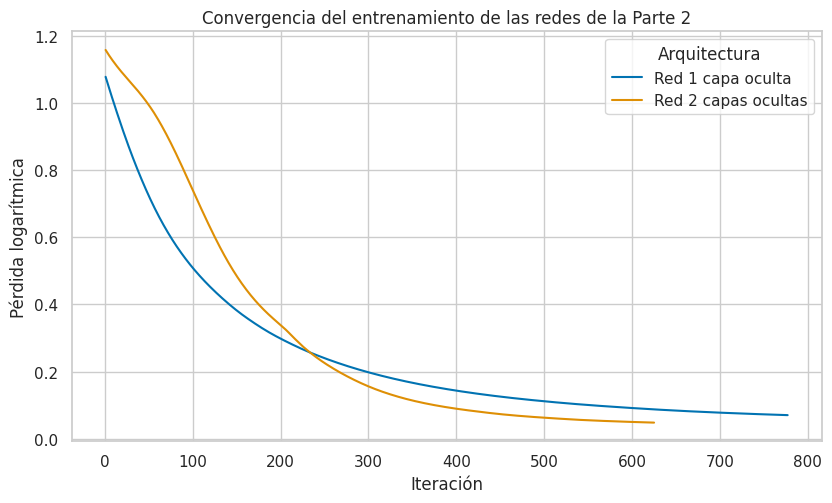

In [13]:
fig, ax = plt.subplots(figsize=(8.5, 5.2))
for nombre_modelo, pipeline_red in modelos_redes.items():
    curva = pipeline_red.named_steps['modelo'].loss_curve_
    ax.plot(range(1, len(curva) + 1), curva, label=nombre_modelo)

ax.set(
    title='Convergencia del entrenamiento de las redes de la Parte 2',
    xlabel='Iteración', ylabel='Pérdida logarítmica'
)
ax.legend(title='Arquitectura')
fig.tight_layout()
fig.savefig(
    figuras / 'S2_figura_07_curvas_perdida_redes_parte2.png',
    dpi=220, bbox_inches='tight'
)
plt.show()


### Interpretación técnica por arquitectura

**Red con una capa oculta (C9).** La arquitectura `(16,)` contiene 131 parámetros entrenables. Alcanzó *accuracy* de entrenamiento 0,9750, *accuracy* de prueba 0,9667 y F1 macro 0,9666. Terminó en 777 iteraciones con pérdida final 0,0704. La brecha entrenamiento-prueba de 0,0083 es pequeña, por lo que en esta partición no se observa una señal importante de sobreajuste.

**Red con dos capas ocultas (C10).** La arquitectura `(16, 8)` contiene 243 parámetros entrenables. Alcanzó *accuracy* de entrenamiento 0,9833, *accuracy* de prueba 0,9667 y F1 macro 0,9666. Terminó en 625 iteraciones con pérdida final 0,0481. Aunque ajustó mejor los datos de entrenamiento, no mejoró el desempeño de prueba respecto de la red de una capa y su brecha aumentó a 0,0167. Por lo tanto, la complejidad adicional todavía no demuestra una ventaja de generalización.

La Parte 3 incorpora la red de tres capas ocultas, calcula matrices de confusión y métricas homogéneas para las tres arquitecturas, y fundamenta la selección técnica final.


## 13. Validaciones automáticas y traspaso técnico desde la Parte 2

### Qué hace este bloque

Comprueba la arquitectura de ambas redes, la integridad de las métricas, la convergencia y la existencia de todos los archivos generados. Si algo falta, la ejecución se detiene con un mensaje identificable.

### Resultado esperado

Debe imprimir que la Parte 2 fue ejecutada y validada, que se entrenaron dos redes y que se verificaron nueve artefactos.

### Errores frecuentes

- Ejecutar solo celdas aisladas y dejar variables antiguas en memoria.
- Guardar el notebook sin sus resultados visibles.
- Moverlo fuera de la estructura de carpetas y perder las rutas relativas.
- Renombrar variables que la Parte 3 debe reutilizar: `modelos_redes`, `predicciones_redes`, `resultados_redes_parte2`, `X_train_clas`, `X_test_clas`, `y_train_clas` y `y_test_clas`.


In [14]:
columnas_metricas_parte2 = [
    'accuracy_train', 'accuracy_test', 'precision_macro_test',
    'recall_macro_test', 'f1_macro_test'
]

assert set(modelos_redes) == set(arquitecturas_parte2)
assert modelos_redes['Red 1 capa oculta'].named_steps['modelo'].hidden_layer_sizes == (16,)
assert modelos_redes['Red 2 capas ocultas'].named_steps['modelo'].hidden_layer_sizes == (16, 8)
assert all(
    isinstance(modelos_redes[nombre], Pipeline)
    for nombre in arquitecturas_parte2
)
assert resultados_redes_parte2[columnas_metricas_parte2].notna().all().all()
assert resultados_redes_parte2[columnas_metricas_parte2].apply(
    lambda columna: columna.between(0, 1).all()
).all()
assert resultados_redes_parte2['convergio_antes_max_iter'].all()
assert all(len(pred) == len(y_test_clas) for pred in predicciones_redes.values())

artefactos_parte2 = [
    figuras / 'S2_figura_05_distribucion_clases.png',
    figuras / 'S2_figura_06_variables_por_especie.png',
    figuras / 'S2_figura_07_curvas_perdida_redes_parte2.png',
    salida / 'S2_distribucion_clases.csv',
    salida / 'S2_resumen_variables_clasificacion.csv',
    salida / 'S2_relevancia_variables_clasificacion.csv',
    salida / 'S2_ficha_tecnica_redes_parte2.csv',
    salida / 'S2_metricas_preliminares_redes_parte2.csv',
    salida / 'S2_predicciones_redes_parte2.csv'
]
faltantes_parte2 = [str(ruta) for ruta in artefactos_parte2 if not ruta.exists()]
assert not faltantes_parte2, f'Artefactos faltantes de la Parte 2: {faltantes_parte2}'

print('✅ Parte 2 ejecutada y validada sin errores.')
print(f'✅ Redes entrenadas: {len(modelos_redes)}')
print(f'✅ Artefactos verificados: {len(artefactos_parte2)}')
print('✅ Variables de traspaso disponibles para la Parte 3.')


✅ Parte 2 ejecutada y validada sin errores.
✅ Redes entrenadas: 2
✅ Artefactos verificados: 9
✅ Variables de traspaso disponibles para la Parte 3.


## 14. Evidencias y traspaso técnico utilizado para la Parte 3

### Archivos generados por la Parte 2

- S2_distribucion_clases.csv
- S2_resumen_variables_clasificacion.csv
- S2_relevancia_variables_clasificacion.csv
- S2_ficha_tecnica_redes_parte2.csv
- S2_metricas_preliminares_redes_parte2.csv
- S2_predicciones_redes_parte2.csv
- S2_figura_05_distribucion_clases.png
- S2_figura_06_variables_por_especie.png
- S2_figura_07_curvas_perdida_redes_parte2.png

### Traspaso técnico

La Parte 3 utiliza las variables ejecutadas `X_train_clas`, `X_test_clas`, `y_train_clas`, `y_test_clas`, `modelos_redes`, `predicciones_redes` y `resultados_redes_parte2`.

Se conservan la semilla 42, el escalamiento mediante `StandardScaler` y los parámetros comunes definidos en la Parte 2. Esta continuidad permite evaluar las arquitecturas con una, dos y tres capas ocultas bajo las mismas condiciones experimentales.

A partir de estos objetos, la Parte 3 incorpora la red neuronal con tres capas ocultas, genera las matrices de confusión, calcula métricas homogéneas para las tres arquitecturas, realiza la comparación técnica de resultados y fundamenta la selección final del modelo.

### Fuentes técnicas para esta parte

- Scikit-learn Developers. (2026). MLPClassifier.
- Scikit-learn Developers. (2026). Pipeline.
- Scikit-learn Developers. (2026). StandardScaler.

Estas referencias complementan las fuentes incorporadas previamente en el proyecto y respaldan la implementación de redes neuronales, pipelines y procesos de estandarización utilizados en esta evaluación.

El informe final deberá asegurar la correspondencia entre citas y referencias, verificando la presencia de fuentes docentes, documentación técnica oficial y bibliografía académica conforme a los criterios establecidos en la rúbrica.


# Parte 3 — Evaluación comparativa y cierre

## 15. Red neuronal con tres capas ocultas (C11)

En esta sección se implementa una red neuronal con tres capas ocultas de 16, 8 y 4 neuronas. Para asegurar una comparación consistente con las arquitecturas anteriores, se mantienen las mismas variables predictoras, la partición entrenamiento/prueba, la semilla, el escalamiento y los hiperparámetros comunes.

La incorporación de una tercera capa permite analizar si un aumento en la profundidad de la red mejora la clasificación de las especies del dataset Iris, manteniendo constantes las demás condiciones experimentales.


In [15]:
# Verificación de variables recibidas desde la Parte 2

variables_requeridas_parte3 = [
    'X_train_clas',
    'X_test_clas',
    'y_train_clas',
    'y_test_clas',
    'modelos_redes',
    'predicciones_redes',
    'resultados_redes_parte2',
    'configuracion_comun_mlp',
    'contar_parametros_mlp',
    'salida',
    'figuras',
    'nombres_clases'
]

variables_faltantes = [
    nombre for nombre in variables_requeridas_parte3
    if nombre not in globals()
]

assert not variables_faltantes, (
    f"Faltan variables de la Parte 2: {variables_faltantes}"
)

print("Variables recibidas correctamente desde la Parte 2.")
print("Entrenamiento:", X_train_clas.shape)
print("Prueba:", X_test_clas.shape)
print("Modelos anteriores:", list(modelos_redes.keys()))

Variables recibidas correctamente desde la Parte 2.
Entrenamiento: (120, 4)
Prueba: (30, 4)
Modelos anteriores: ['Red 1 capa oculta', 'Red 2 capas ocultas']


In [16]:
# ============================================================
# RED NEURONAL CON TRES CAPAS OCULTAS
# Arquitectura: 16, 8 y 4 neuronas
# ============================================================

nombre_modelo_3_capas = 'Red 3 capas ocultas'
arquitectura_3_capas = (16, 8, 4)


# 1. Construcción del pipeline
pipeline_red_3_capas = Pipeline([
    (
        'escalador',
        StandardScaler()
    ),
    (
        'modelo',
        MLPClassifier(
            hidden_layer_sizes=arquitectura_3_capas,
            **configuracion_comun_mlp
        )
    )
])


# 2. Entrenamiento
pipeline_red_3_capas.fit(
    X_train_clas,
    y_train_clas
)


# 3. Predicciones
pred_train_3_capas = pipeline_red_3_capas.predict(
    X_train_clas
)

pred_test_3_capas = pipeline_red_3_capas.predict(
    X_test_clas
)


# 4. Acceso al modelo MLP entrenado
mlp_3_capas = pipeline_red_3_capas.named_steps['modelo']


# 5. Métricas de entrenamiento y prueba
accuracy_train_3_capas = accuracy_score(
    y_train_clas,
    pred_train_3_capas
)

accuracy_test_3_capas = accuracy_score(
    y_test_clas,
    pred_test_3_capas
)

precision_macro_3_capas = precision_score(
    y_test_clas,
    pred_test_3_capas,
    average='macro',
    zero_division=0
)

recall_macro_3_capas = recall_score(
    y_test_clas,
    pred_test_3_capas,
    average='macro',
    zero_division=0
)

f1_macro_3_capas = f1_score(
    y_test_clas,
    pred_test_3_capas,
    average='macro',
    zero_division=0
)

brecha_train_test_3_capas = (
    accuracy_train_3_capas
    - accuracy_test_3_capas
)


# 6. Tabla de resultados preliminares
resultado_red_3_capas = pd.DataFrame([
    {
        'modelo': nombre_modelo_3_capas,
        'accuracy_train': accuracy_train_3_capas,
        'accuracy_test': accuracy_test_3_capas,
        'precision_macro_test': precision_macro_3_capas,
        'recall_macro_test': recall_macro_3_capas,
        'f1_macro_test': f1_macro_3_capas,
        'brecha_train_test': brecha_train_test_3_capas,
        'iteraciones': mlp_3_capas.n_iter_,
        'perdida_final': mlp_3_capas.loss_,
        'convergio_antes_max_iter': (
            mlp_3_capas.n_iter_
            < mlp_3_capas.max_iter
        )
    }
])


# 7. Cálculo del número de parámetros entrenables
parametros_entrenables_3_capas = contar_parametros_mlp(
    X_train_clas.shape[1],
    arquitectura_3_capas,
    y_train_clas.nunique()
)


# 8. Ficha técnica
ficha_red_3_capas = pd.DataFrame([
    {
        'modelo': nombre_modelo_3_capas,
        'capas_ocultas': len(arquitectura_3_capas),
        'neuronas_por_capa': str(arquitectura_3_capas),
        'parametros_entrenables': parametros_entrenables_3_capas,
        'activacion': configuracion_comun_mlp['activation'],
        'optimizador': configuracion_comun_mlp['solver'],
        'alpha_L2': configuracion_comun_mlp['alpha'],
        'tasa_aprendizaje_inicial': (
            configuracion_comun_mlp[
                'learning_rate_init'
            ]
        ),
        'max_iter': configuracion_comun_mlp['max_iter'],
        'semilla': configuracion_comun_mlp[
            'random_state'
        ],
        'preprocesamiento': (
            'StandardScaler ajustado exclusivamente '
            'con entrenamiento'
        )
    }
])


# 9. Incorporación de la tercera red a los objetos existentes
modelos_redes[nombre_modelo_3_capas] = (
    pipeline_red_3_capas
)

predicciones_redes[nombre_modelo_3_capas] = (
    pred_test_3_capas
)


# 10. Presentación de resultados
print('FICHA TÉCNICA DE LA RED CON TRES CAPAS')
display(ficha_red_3_capas)

print('MÉTRICAS PRELIMINARES')
display(resultado_red_3_capas.round(4))

print('Red neuronal con tres capas entrenada correctamente.')
print('Arquitectura:', arquitectura_3_capas)
print('Parámetros entrenables:', parametros_entrenables_3_capas)
print('Iteraciones:', mlp_3_capas.n_iter_)
print('Pérdida final:', round(mlp_3_capas.loss_, 6))

FICHA TÉCNICA DE LA RED CON TRES CAPAS


,modelo,capas_ocultas,neuronas_por_capa,parametros_entrenables,activacion,optimizador,alpha_L2,tasa_aprendizaje_inicial,max_iter,semilla,preprocesamiento
0,Red 3 capas ocultas,3,"(16, 8, 4)",267,relu,adam,0.0001,0.001,2000,42,StandardScaler ajustado exclusivamente con ent...


MÉTRICAS PRELIMINARES


,modelo,accuracy_train,accuracy_test,precision_macro_test,recall_macro_test,f1_macro_test,brecha_train_test,iteraciones,perdida_final,convergio_antes_max_iter
0,Red 3 capas ocultas,0.9917,0.9333,0.9333,0.9333,0.9333,0.0583,613,0.0251,True


Red neuronal con tres capas entrenada correctamente.
Arquitectura: (16, 8, 4)
Parámetros entrenables: 267
Iteraciones: 613
Pérdida final: 0.025051


### Interpretación técnica de la red con tres capas ocultas

La red neuronal con tres capas ocultas, configurada con una arquitectura de 16, 8 y 4 neuronas, alcanzó un accuracy de entrenamiento de 0,9917 y un accuracy de prueba de 0,9333. Asimismo, obtuvo valores de 0,9333 en precision macro, recall macro y F1 macro.

La diferencia de 0,0583 entre el accuracy de entrenamiento y el accuracy de prueba muestra que el desempeño disminuye al evaluar observaciones no utilizadas durante el ajuste. Esta brecha debe considerarse en la comparación final, ya que una mayor profundidad no garantiza automáticamente una mejor capacidad de generalización.

El entrenamiento finalizó después de 613 iteraciones, antes del máximo de 2.000, con una pérdida final de 0,025051. Por lo tanto, el modelo cumplió el criterio de convergencia definido dentro de la configuración experimental.

Aunque la arquitectura de tres capas posee una mayor capacidad representacional, sus resultados preliminares son inferiores a los obtenidos por las redes de una y dos capas ocultas. No obstante, la selección definitiva debe fundamentarse mediante las matrices de confusión, las métricas homogéneas de las tres arquitecturas y el análisis de fortalezas y limitaciones.

## 16. Desempeño de las redes neuronales (C12)

En esta sección se evalúan homogéneamente las tres arquitecturas de redes neuronales sobre el mismo conjunto de prueba. Para cada modelo se calcula su matriz de confusión y las métricas accuracy, precision macro, recall macro y F1 macro.

El uso de métricas macro permite asignar la misma importancia a las tres especies del dataset Iris, independientemente de su frecuencia. Aunque las clases se encuentran balanceadas, esta estrategia facilita una comparación consistente del desempeño entre Setosa, Versicolor y Virginica.

Las matrices de confusión permitirán identificar no solo la cantidad total de predicciones correctas, sino también las especies en las que se concentran los errores de clasificación.

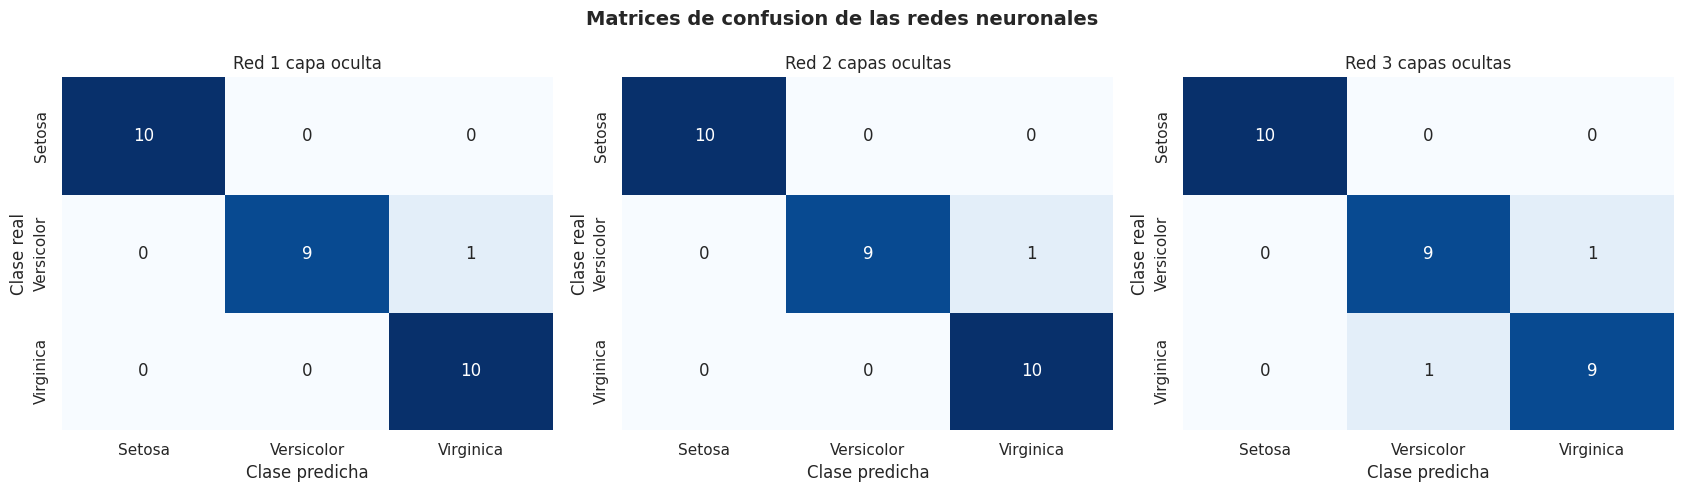


Red 1 capa oculta
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Red 2 capas ocultas
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Red 3 capas ocultas
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Matrices de confusion generadas correctamente.
Figura guardada en: /content/05_Figuras/S2_figura_08_matrices_confusion_redes.png
Tabla CSV guardada en: /content/06_Resultados/S2_matrices_confusion_redes.csv


In [17]:
# ============================================================
# MATRICES DE CONFUSION DE LAS TRES ARQUITECTURAS
# ============================================================

from sklearn.metrics import confusion_matrix

# Orden de presentacion de los modelos
orden_modelos = [
    'Red 1 capa oculta',
    'Red 2 capas ocultas',
    'Red 3 capas ocultas'
]

# Nombres de las clases
etiquetas_clases = [
    'Setosa',
    'Versicolor',
    'Virginica'
]

# Objetos para almacenar resultados
matrices_confusion_redes = {}
filas_matrices_confusion = []

# Crear una figura con tres espacios
fig, axes = plt.subplots(
    1,
    3,
    figsize=(17, 5)
)

# Calcular y mostrar una matriz por modelo
for ax, nombre_modelo in zip(axes, orden_modelos):

    predicciones_modelo = predicciones_redes[nombre_modelo]

    matriz = confusion_matrix(
        y_test_clas,
        predicciones_modelo,
        labels=[0, 1, 2]
    )

    matrices_confusion_redes[nombre_modelo] = matriz

    # Guardar cada valor de la matriz en formato tabulado
    for clase_real in range(3):
        for clase_predicha in range(3):

            filas_matrices_confusion.append({
                'modelo': nombre_modelo,
                'clase_real_codigo': clase_real,
                'clase_real': etiquetas_clases[clase_real],
                'clase_predicha_codigo': clase_predicha,
                'clase_predicha': etiquetas_clases[clase_predicha],
                'cantidad': int(
                    matriz[clase_real, clase_predicha]
                )
            })

    # Dibujar la matriz
    sns.heatmap(
        matriz,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        xticklabels=etiquetas_clases,
        yticklabels=etiquetas_clases,
        ax=ax
    )

    ax.set_title(nombre_modelo)
    ax.set_xlabel('Clase predicha')
    ax.set_ylabel('Clase real')

# Titulo general
fig.suptitle(
    'Matrices de confusion de las redes neuronales',
    fontsize=14,
    fontweight='bold'
)

fig.tight_layout()

# Ruta de la figura
ruta_figura_matrices = (
    figuras / 'S2_figura_08_matrices_confusion_redes.png'
)

# Guardar figura
fig.savefig(
    ruta_figura_matrices,
    dpi=220,
    bbox_inches='tight'
)

plt.show()

# Crear tabla tabulada
tabla_matrices_confusion = pd.DataFrame(
    filas_matrices_confusion
)

# Ruta del archivo CSV
ruta_csv_matrices = (
    salida / 'S2_matrices_confusion_redes.csv'
)

# Guardar tabla en CSV
tabla_matrices_confusion.to_csv(
    ruta_csv_matrices,
    index=False,
    encoding='utf-8-sig'
)

# Mostrar matrices numericamente
for nombre_modelo in orden_modelos:
    print()
    print(nombre_modelo)
    print(matrices_confusion_redes[nombre_modelo])

print()
print('Matrices de confusion generadas correctamente.')
print('Figura guardada en:', ruta_figura_matrices)
print('Tabla CSV guardada en:', ruta_csv_matrices)

### Interpretación de las matrices de confusión

Las redes neuronales con una y dos capas ocultas presentan el mismo comportamiento sobre las 30 observaciones del conjunto de prueba. Ambas clasifican correctamente las 10 observaciones de Setosa y las 10 observaciones de Virginica. En la clase Versicolor, cada arquitectura clasifica correctamente 9 observaciones y confunde una observación con Virginica. En consecuencia, ambas redes alcanzan 29 clasificaciones correctas de un total de 30.

La red con tres capas ocultas clasifica correctamente las 10 observaciones de Setosa, 9 observaciones de Versicolor y 9 observaciones de Virginica. Los dos errores se producen entre Versicolor y Virginica: una observación de Versicolor es clasificada como Virginica y una observación de Virginica es clasificada como Versicolor. Esta arquitectura alcanza 28 clasificaciones correctas de un total de 30.

Los resultados muestran que Setosa es la clase más fácilmente diferenciable para las tres redes. Los errores se concentran entre Versicolor y Virginica, lo que es coherente con la mayor superposición observada previamente entre estas especies en algunas de sus características morfológicas.

La incorporación de una tercera capa oculta no mejora el desempeño sobre el conjunto de prueba. Por el contrario, agrega un error adicional respecto de las arquitecturas de una y dos capas. Sin embargo, la selección definitiva debe considerar conjuntamente las matrices de confusión, las métricas macro, la brecha entre entrenamiento y prueba, la complejidad y la convergencia de cada arquitectura.

### Comparación homogénea de métricas de clasificación

A continuación, se consolidan las métricas obtenidas por las redes neuronales con una, dos y tres capas ocultas. La comparación considera accuracy de entrenamiento y prueba, precision macro, recall macro, F1 macro, brecha entre entrenamiento y prueba, número de iteraciones y pérdida final.

Esta evaluación permite analizar conjuntamente el desempeño predictivo, la capacidad de generalización y el comportamiento del proceso de entrenamiento de cada arquitectura.

In [18]:
# Consolidar resultados de las tres arquitecturas

resultados_redes_final = pd.concat([resultados_redes_parte2, resultado_red_3_capas], ignore_index=True)

orden_modelos_final = ['Red 1 capa oculta', 'Red 2 capas ocultas', 'Red 3 capas ocultas']

resultados_redes_final['orden'] = resultados_redes_final['modelo'].map({
    'Red 1 capa oculta': 1,
    'Red 2 capas ocultas': 2,
    'Red 3 capas ocultas': 3
})

resultados_redes_final = resultados_redes_final.sort_values('orden').reset_index(drop=True)

columnas_metricas = ['modelo', 'accuracy_train', 'accuracy_test', 'precision_macro_test', 'recall_macro_test', 'f1_macro_test', 'brecha_train_test', 'iteraciones', 'perdida_final', 'convergio_antes_max_iter']

tabla_metricas_redes = resultados_redes_final.loc[:, columnas_metricas].copy()

print('METRICAS CONSOLIDADAS DE LAS TRES ARQUITECTURAS')

display(tabla_metricas_redes.round(4))

ruta_csv_metricas_redes = salida / 'S2_metricas_finales_redes.csv'

tabla_metricas_redes.to_csv(ruta_csv_metricas_redes, index=False, encoding='utf-8-sig')

print('Tabla consolidada generada correctamente.')
print('Cantidad de arquitecturas:', len(tabla_metricas_redes))
print('Archivo guardado en:', ruta_csv_metricas_redes)

METRICAS CONSOLIDADAS DE LAS TRES ARQUITECTURAS


,modelo,accuracy_train,accuracy_test,precision_macro_test,recall_macro_test,f1_macro_test,brecha_train_test,iteraciones,perdida_final,convergio_antes_max_iter
0,Red 1 capa oculta,0.9750,0.9667,0.9697,0.9667,0.9666,0.0083,777,0.0704,True
1,Red 2 capas ocultas,0.9833,0.9667,0.9697,0.9667,0.9666,0.0167,625,0.0481,True
2,Red 3 capas ocultas,0.9917,0.9333,0.9333,0.9333,0.9333,0.0583,613,0.0251,True


Tabla consolidada generada correctamente.
Cantidad de arquitecturas: 3
Archivo guardado en: /content/06_Resultados/S2_metricas_finales_redes.csv


### Interpretación del desempeño global

Las redes neuronales con una y dos capas ocultas alcanzaron el mejor desempeño sobre el conjunto de prueba, con un accuracy de 0,9667 y un F1 macro de 0,9666. Estos resultados muestran que ambas arquitecturas clasificaron correctamente 29 de las 30 observaciones utilizadas para la evaluación.

La red con una capa oculta obtuvo un accuracy de entrenamiento de 0,9750 y una brecha entre entrenamiento y prueba de 0,0083. Por su parte, la red con dos capas alcanzó un accuracy de entrenamiento de 0,9833 y una brecha de 0,0167. Aunque ambas presentan el mismo desempeño en prueba, la primera arquitectura muestra una menor diferencia entre entrenamiento y prueba.

La red con tres capas ocultas alcanzó un accuracy y un F1 macro de 0,9333, correspondientes a 28 clasificaciones correctas de un total de 30. Su brecha entre entrenamiento y prueba fue de 0,0583, superior a la observada en las otras arquitecturas.

Las tres redes finalizaron antes del máximo de 2.000 iteraciones. La red con una capa necesitó 777 iteraciones, la red con dos capas 625 y la red con tres capas 613. Aunque la arquitectura de tres capas obtuvo la menor pérdida final, este resultado no se tradujo en un mejor desempeño sobre datos no utilizados durante el entrenamiento.

En conjunto, los resultados indican que agregar profundidad aumentó la complejidad del modelo, pero no mejoró la capacidad de clasificación sobre el conjunto de prueba. La evaluación confirma que la selección de una arquitectura no debe basarse únicamente en la pérdida de entrenamiento, sino también en su desempeño de prueba, estabilidad y capacidad de generalización.

## 17. Comparación de arquitecturas de redes neuronales (C13)

La comparación técnica considera el desempeño en prueba, la brecha entre entrenamiento y prueba, la complejidad de cada arquitectura, el proceso de convergencia y los errores observados en las matrices de confusión.

Aunque las redes con una y dos capas ocultas alcanzaron métricas idénticas sobre el conjunto de prueba, ambas presentan diferencias en complejidad y generalización. La red con tres capas posee una mayor capacidad representacional, pero dicha profundidad adicional no se tradujo en un mejor desempeño predictivo.

### Comparación técnica de las arquitecturas

| Arquitectura | Capas ocultas | Parámetros entrenables | Accuracy prueba | F1 macro | Brecha train-test | Fortalezas | Limitaciones |
|---|---:|---:|---:|---:|---:|---|---|
| Red 1 capa oculta | 1: (16,) | 131 | 0,9667 | 0,9666 | 0,0083 | Mejor equilibrio entre desempeño, simplicidad y generalización. Registra 29 aciertos de 30 y la menor brecha entre entrenamiento y prueba. | Necesitó 777 iteraciones, la mayor cantidad entre las tres arquitecturas. Mantiene un error entre Versicolor y Virginica. |
| Red 2 capas ocultas | 2: (16, 8) | 243 | 0,9667 | 0,9666 | 0,0167 | Iguala el mejor desempeño de prueba y converge en menos iteraciones que la red de una capa. | Su mayor complejidad no mejora las métricas de prueba y presenta una brecha train-test superior a la red de una capa. |
| Red 3 capas ocultas | 3: (16, 8, 4) | 267 | 0,9333 | 0,9333 | 0,0583 | Presenta la mayor capacidad representacional, la menor pérdida final y converge antes del máximo establecido. | Obtiene el menor desempeño de prueba, la mayor brecha train-test y dos errores entre Versicolor y Virginica. |

### Selección técnica de la arquitectura

La arquitectura seleccionada corresponde a la **red neuronal con una capa oculta de 16 neuronas**. Esta decisión se fundamenta en que alcanza el mejor desempeño de prueba, con un accuracy de 0,9667 y un F1 macro de 0,9666, igualando a la red de dos capas, pero utilizando una arquitectura más simple y una menor cantidad de parámetros entrenables.

Además, presenta la menor brecha entre entrenamiento y prueba, con un valor de 0,0083, lo que evidencia el comportamiento más estable entre las arquitecturas evaluadas. Su matriz de confusión registra 29 clasificaciones correctas de un total de 30, con un único error entre Versicolor y Virginica.

La red de dos capas no aporta una mejora en las métricas de prueba pese a aumentar la complejidad del modelo. La red de tres capas obtiene una menor pérdida final de entrenamiento, pero presenta un accuracy y un F1 macro inferiores, además de una mayor brecha de generalización. Por esta razón, una menor pérdida de entrenamiento no constituye evidencia suficiente para preferir una arquitectura más profunda.

En consecuencia, la red con una capa oculta representa la alternativa más pertinente para este problema, debido a que ofrece el mejor equilibrio entre desempeño predictivo, generalización, complejidad e interpretabilidad de su configuración.

## 18. Conclusiones integradas (C14)

La Evaluación Sumativa 2 permitió consolidar el desarrollo del proyecto mediante la implementación de modelos de regresión supervisada y redes neuronales aplicadas a clasificación multiclase sobre el dataset Iris. El flujo analítico mantuvo criterios comunes de reproducibilidad, utilizando una semilla 42, una partición estratificada de 80 % para entrenamiento y 20 % para prueba, y una preparación diferenciada según las características de cada problema.

En el bloque de regresión, el objetivo consistió en predecir el ancho del pétalo a partir de su largo. Se compararon seis familias de modelos bajo un procedimiento de validación cruzada y ajuste de hiperparámetros. El modelo SVR presentó el mejor desempeño, con un MSE de 0,0403, un RMSE de 0,2007 cm y un R² de 0,9303. Estos resultados indican que el modelo logró explicar una proporción elevada de la variabilidad observada en el ancho del pétalo, manteniendo un error de predicción acotado en la unidad original de la variable objetivo.

En el bloque de clasificación se utilizaron las cuatro variables morfológicas del dataset para predecir la especie de cada flor. La distribución equilibrada de las clases permitió evaluar los modelos sin aplicar técnicas de sobremuestreo ni ponderación. Asimismo, la estandarización mediante StandardScaler se incorporó dentro de cada Pipeline y se ajustó exclusivamente con los datos de entrenamiento, evitando fuga de información y asegurando una comparación consistente entre arquitecturas.

Las redes neuronales con una y dos capas ocultas alcanzaron el mejor desempeño sobre el conjunto de prueba, con un accuracy de 0,9667 y un F1 macro de 0,9666. Ambas clasificaron correctamente 29 de las 30 observaciones de prueba. La red con tres capas obtuvo un accuracy y un F1 macro de 0,9333, con 28 clasificaciones correctas y una brecha train-test de 0,0583.

Las matrices de confusión mostraron que Setosa fue correctamente identificada por las tres arquitecturas. Los errores se concentraron entre Versicolor y Virginica, resultado coherente con la mayor superposición observada entre estas especies durante el análisis exploratorio.

La arquitectura seleccionada corresponde a la red con una capa oculta de 16 neuronas. Esta red igualó el mejor desempeño de prueba, utilizó la menor cantidad de parámetros entrenables y presentó la menor brecha entre entrenamiento y prueba, con un valor de 0,0083. En consecuencia, ofreció el mejor equilibrio entre desempeño predictivo, generalización y complejidad.

Los resultados muestran que aumentar la profundidad de una red neuronal no garantiza automáticamente una mejora en datos no observados. La red con tres capas alcanzó la menor pérdida final de entrenamiento, pero obtuvo el desempeño más bajo en prueba y la mayor brecha de generalización. Por ello, la selección del modelo final debe considerar conjuntamente las métricas de prueba, las matrices de confusión, la estabilidad y la complejidad de cada arquitectura.

Como proyección, se recomienda evaluar la estabilidad de los resultados mediante validación cruzada específica para clasificación, ampliar la búsqueda de hiperparámetros y analizar el comportamiento de los modelos en nuevas particiones o conjuntos de datos. Estas acciones permitirían determinar si la ventaja observada por la red de una capa se mantiene más allá de la partición utilizada en esta evaluación.

## 19. Evidencias y validación final de la Parte 3

Esta sección consolida los archivos generados durante la implementación de la tercera arquitectura, la evaluación homogénea de las redes neuronales y la comparación final. Además, incorpora validaciones automáticas para comprobar la existencia de los tres modelos, sus predicciones, métricas, matrices de confusión y artefactos exportados.

Las evidencias generadas permiten mantener la trazabilidad entre el notebook, el informe final, las carpetas de figuras y resultados, y el repositorio del proyecto.

In [19]:
# Validacion ampliada de la Parte 3

print('INICIANDO VALIDACION AMPLIADA')

assert tabla_metricas_redes.shape[0] == 3
assert tabla_metricas_redes['accuracy_test'].between(0, 1).all()
assert tabla_metricas_redes['f1_macro_test'].between(0, 1).all()
assert tabla_metricas_redes['iteraciones'].le(2000).all()

assert len(predicciones_redes) == 3
assert len(predicciones_redes['Red 3 capas ocultas']) == 30

assert ficha_red_3_capas.shape[0] == 1
assert resultado_red_3_capas.shape[0] == 1
assert arquitectura_3_capas == (16, 8, 4)

assert ruta_figura_matrices.exists()
assert ruta_csv_matrices.exists()
assert ruta_csv_metricas_redes.exists()

print('VALIDACION AMPLIADA SUPERADA')
print('Arquitecturas evaluadas:', tabla_metricas_redes.shape[0])
print('Predicciones por arquitectura:', len(y_test_clas))
print('Arquitectura de tres capas:', arquitectura_3_capas)
print('Figura de matrices:', ruta_figura_matrices.name)
print('CSV de matrices:', ruta_csv_matrices.name)
print('CSV de metricas:', ruta_csv_metricas_redes.name)

INICIANDO VALIDACION AMPLIADA
VALIDACION AMPLIADA SUPERADA
Arquitecturas evaluadas: 3
Predicciones por arquitectura: 30
Arquitectura de tres capas: (16, 8, 4)
Figura de matrices: S2_figura_08_matrices_confusion_redes.png
CSV de matrices: S2_matrices_confusion_redes.csv
CSV de metricas: S2_metricas_finales_redes.csv
